In [3]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
import numpy as np
import math
from scipy import stats
import random

import keras
import bayesflow as bf
from functools import partial

import numba as nb
from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32
import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)

import pandas as pd

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
RNG = np.random.default_rng(SEED)
rng_states = create_xoroshiro128p_states(2000*2400, seed=SEED)

INFO:bayesflow:Using backend 'jax'


In [4]:
import importlib, sys, subprocess

print("=== Python ===")
print(sys.version)

print("\n=== Package Versions ===")
for pkg_name in ["keras", "bayesflow", "numpy", "pandas", "matplotlib", "seaborn", "numba", "jax", "jaxlib"]:
    try:
        mod = importlib.import_module(pkg_name)
        print(f"{pkg_name}: {getattr(mod, '__version__', 'unknown')}")
    except ImportError:
        print(f"{pkg_name}: NOT INSTALLED")


print("\n=== CUDA / GPU Info ===")
try:
    print(f"CUDA available: {cuda.is_available()}")
    if cuda.is_available():
        print(f"GPU: {cuda.get_current_device().name}")
except Exception as e:
    print(f"CUDA check failed: {e}")

=== Python ===
3.11.3 (main, Aug 13 2025, 16:49:22) [GCC 12.3.0]

=== Package Versions ===
keras: 3.11.3
bayesflow: 2.0.6
numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.10.6
seaborn: 0.13.2
numba: 0.62.1
jax: 0.4.28
jaxlib: 0.4.28

=== CUDA / GPU Info ===
CUDA available: True
GPU: b'NVIDIA H100 80GB HBM3'


## Single trial simulation
The following cells implement the core simulation using raw CUDA kernels.
**You do not need to modify this code** to customize the model.

In [5]:
@cuda.jit
def cuda_diffusion_trial(rng_states, out_rt, out_resp, in_l, in_phi, in_a, in_zx, in_zy, in_ndt, dt, max_steps, num_threads):
    """Simulates a trial from the diffusion model."""
    
    thread_id = cuda.grid(1)

    if (thread_id < num_threads):
        l = in_l[thread_id]
        phi = in_phi[thread_id]
        a = in_a[thread_id]
        zx = in_zx[thread_id]
        zy = in_zy[thread_id]
        ndt = in_ndt[thread_id]

        n_steps = 0
        x = zx * a 
        y = zy * a

        x_target = a * math.cos(phi)
        y_target = a * math.sin(phi)

        V_x = x_target - x
        V_y = y_target - y

        magnitude = math.sqrt(V_x**2 + V_y**2)
        vx = l * (V_x / magnitude)
        vy = l * (V_y / magnitude)
        
        mu_x = vx * dt
        mu_y = vy * dt
        
        sigma = math.sqrt(dt)

        # Simulate a single DM path
        for n_steps in range(max_steps):
            # Generate random noise
            dx = mu_x + sigma * xoroshiro128p_normal_float32(rng_states, thread_id)
            dy = mu_y + sigma * xoroshiro128p_normal_float32(rng_states, thread_id)
            
            # Check if step would cross the boundary (y + dy <= 0)
            if y + dy <= 0:
                # Calculate exactly where we hit the boundary
                # We need to find t such that y + t * dy = 0
                # So t = -y / dy (assuming dy != 0)
                
                if abs(dy) > 1e-12:  # Avoid division by zero
                    t_boundary = -y / dy  # Fraction of step to reach boundary
                    
                    # Move to the boundary
                    x_boundary = x + t_boundary * dx
                    y_boundary = 0.0  # Exactly at boundary
                    
                    # Calculate remaining step after hitting boundary
                    dx_remaining = (1.0 - t_boundary) * dx
                    dy_remaining = (1.0 - t_boundary) * dy
                    
                    # Reflect the remaining step (flip y-component)
                    dx_reflected = dx_remaining
                    dy_reflected = -dy_remaining
                    
                    # Apply the reflected remaining step
                    x = x_boundary + dx_reflected
                    y = y_boundary + dy_reflected
                    
                else:
                    # If dy is essentially zero, just move horizontally
                    x += dx
                    # y stays the same (no vertical movement)
                    
            else:
                # Normal step - no boundary crossing
                x += dx
                y += dy
                    
            # Check if we've reached the circular boundary
            if x**2 + y**2 >= a**2:
                break
            
        rt = float(n_steps) * dt
        resp = math.atan2(y, x)
         
        out_rt[thread_id] = rt + ndt
        out_resp[thread_id] = resp


## ⚙️Prior (customizable)

This function defines the prior distributions over all model parameters.
Modify the ranges below to match your experimental design.

### Parameter guide

| Parameter | Shape | Description | Default range |
|-----------|-------|-------------|---------------|
| `l` | `(batch_size, n_conditions)` | Drift rate length | [0.5, 9] |
| `phi` | `(batch_size, n_conditions)` | Drift rate direction | [0, π] |
| `zx` | `(batch_size, 1)` | Starting point (x-axis) | [-0.7, 0.7] |
| `zy` | `(batch_size, 1)` | Starting point (y-axis) | [0, 0.7] |
| `a` | `(batch_size, 1)` | Decision threshold | [0.5, 9] |
| `ndt` | `(batch_size, 1)` | Non-decision time (seconds) | [0.1, 2.5] |

### Common modifications

**Change parameter ranges:**
```python
a = rng.uniform(0.5, 9, size=batch_size)  # change 0.5 and 9
```

**Change number of conditions** (default: 4):
```python
l = rng.uniform(0.5, 9, size = (batch_size, 4))  # change 4 → your n_conditions
phi = rng.uniform(0, np.pi, size=(batch_size, 4))   # change 4 → your n_conditions
```

**Make a shared parameter condition-specific:**
```python
# shared (current default)
a = rng.uniform(0.5, 9, size=batch_size)

# condition-specific
a = rng.uniform(0.5, 9, size=(batch_size, 4))  # one threshold per condition
a = a.reshape(batch_size, 4)                    # update reshape accordingly
```

In [6]:
def diffusion_prior(batch_info, rng=None):
    if rng is None:
        rng = np.random.default_rng()  # np.random，不是rng

    if isinstance(batch_info, tuple):
        batch_size = batch_info[0]
    elif isinstance(batch_info, dict):
        batch_size = batch_info["batch_size"]
    else:
        batch_size = batch_info  # assume int
        
    l = rng.uniform(0.5, 9, size = (batch_size, 4))
    a = rng.uniform(0.5, 9, size = batch_size)
        
    zx = rng.uniform(-0.7, 0.7, size = batch_size)
    zy = rng.uniform(0, 0.7, size = batch_size)

    ndt = rng.uniform(0.1, 2.5, size = batch_size)

 
    phi = rng.uniform(0, np.pi, size=(batch_size, 4)) 

    return {
        "l": l,
        "phi": phi,
        "a": a.reshape(batch_size, 1),
        "zx": zx.reshape(batch_size, 1),
        "zy": zy.reshape(batch_size, 1),
        "ndt": ndt.reshape(batch_size, 1),
    }



## ⚙️ CUDA simulator wrapper (customizable)

This function prepares data for the CUDA kernel and collects results.
Most users **do not need to modify this function**.

### Global settings

```python
max_n = 200             # maximum observations per dataset
THREADS_PER_BLOCK = 64  # optimalot change
```

> `THREADS_PER_BLOCK = 64` was determined empirically to be optimal for this ker~20x slower).

### Parameters you may need to modify

**Number of conditions** (default: 4):
```python
num_conditions = 4  # change to match your experiment
```

**Maximum observations per dataset** (default: 200):
```python
max_n = 200  # must be >= max(num_obs_per_condition) * n_conditions
```

**Simulation precision:**
```python
cuda_diffusion_trial[blocks, THREADS_PER_BLOCK](
    ...
    1e-3,   # dt — time step size, smaller = more precise but slower
    15000,  # max_steps — maximum integration steps per trial
    ...
)
```

**If you made `a`, `zx`, `zy`, or `ndt` condition-specific in the prior:**

```python
in_a   = a[i_indices, 0].astype(np.float32)

in_a   = a[i_indices, cond_indices].astype(np.float32)
```

### Less optimal, changing will slow down simulation
- The `i_indices` / `k_indices` / `cond_indices` indexing logic — handles batching correctly
- `rng_states` — automatically resized if needed, do not manually set inside the simulator

In [8]:
max_n = 200
THREADS_PER_BLOCK = 64 

def cuda_convert_matrix_to(l, phi, a, zx, zy, ndt, batch_size, num_obs, con):
 
    total_threads = batch_size * num_obs
    
    # Convert one-hot condition matrix to condition indices 
    condition_ids = np.argmax(con, axis=-1)  # (batch_size, num_obs)
    
    # Compute flattened indices for batch and observation
    flat_index = np.arange(total_threads)
    i_indices = flat_index // num_obs  # dataset index
    k_indices = flat_index % num_obs   # observation index
    
    # Gather condition indices per observation
    cond_indices = condition_ids[i_indices, k_indices]
    
    # Vectorized lookup of parameters for each trial
    in_l = l[i_indices, cond_indices].astype(np.float32)
    in_phi = phi[i_indices, cond_indices].astype(np.float32)
    in_a = a[i_indices, 0].astype(np.float32)
    in_zx = zx[i_indices, 0].astype(np.float32)
    in_zy = zy[i_indices, 0].astype(np.float32)
    in_ndt = ndt[i_indices, 0].astype(np.float32)
    
    # Transfer to GPU device arrays
    return (
        cuda.to_device(in_l),
        cuda.to_device(in_phi),
        cuda.to_device(in_a),
        cuda.to_device(in_zx),
        cuda.to_device(in_zy),
        cuda.to_device(in_ndt),
    )


@cuda.jit
def kernel_convert_matrix_from(out_rt, out_resp, out):
    idx = cuda.grid(1)
    total_threads = out_rt.size
    
    if idx < total_threads:
        i = idx // out.shape[1]  # batch index
        k = idx % out.shape[1]   # observation index
        
        out[i, k, 0] = out_rt[idx]
        out[i, k, 1] = out_resp[idx]

def cuda_convert_matrix_from_gpu(out_rt, out_resp, batch_size, num_obs):
    # Allocate device output array
    out = cuda.device_array((batch_size, num_obs, 2), dtype=np.float32)
    total_threads = batch_size * num_obs
    blocks = (total_threads + THREADS_PER_BLOCK - 1) // THREADS_PER_BLOCK
    
    kernel_convert_matrix_from[blocks, THREADS_PER_BLOCK](out_rt, out_resp, out)
    
    return out


def cuda_simulator(l, phi, a, zx, zy, ndt, 
                   num_obs_per_condition, 
                   rng=None, *args):
    
    batch_size = l.shape[0]
    num_conditions = 4

    num_obs = int(np.sum(num_obs_per_condition))
    total_threads = int(batch_size * num_obs)
    
    con_labels = np.concatenate([
        np.full(count, i, dtype=int)
        for i, count in enumerate(num_obs_per_condition)
    ])
    con = np.eye(num_conditions)[con_labels]              # (num_obs, num_conditions)
    con = np.tile(con[None, :, :], (batch_size, 1, 1))    # (batch_size, num_obs, num_conditions)

    blocks = math.ceil(total_threads / THREADS_PER_BLOCK)
  
    global rng_states
    total_threads_global = total_threads * THREADS_PER_BLOCK
    if 'rng_states' not in globals() or rng_states.size < total_threads_global:
        rng_states = create_xoroshiro128p_states(total_threads_global, seed=np.random.randint(1, 10000))
    
    # Preallocate output arrays on host
    out_rt = cuda.device_array(total_threads, dtype=np.float32)
    out_resp = cuda.device_array(total_threads, dtype=np.float32)
    
    # Convert parameters to device arrays
    in_l, in_phi, in_a, in_zx, in_zy, in_ndt = cuda_convert_matrix_to(l, phi, a, zx, zy, ndt, batch_size, num_obs, con)
    
    # Launch the main kernel
    cuda_diffusion_trial[blocks, THREADS_PER_BLOCK](rng_states, out_rt, out_resp, in_l, in_phi, in_a, in_zx, in_zy, in_ndt, 1e-3, 15000, total_threads)
    
    # Convert flat outputs to 3D tensor on GPU
    out_device = cuda_convert_matrix_from_gpu(out_rt, out_resp, batch_size, num_obs)
    
    # Copy back to host only once here
    out = out_device.copy_to_host()
    
    rt = out[:, :, 0]
    resp = out[:, :, 1]

  
    rt_min = np.min(rt, axis=1).reshape(batch_size, 1)
    
    pad_len = max_n - num_obs
    if pad_len > 0:
        pad_shape = (batch_size, pad_len)
        pad_shape_con = (batch_size, pad_len, num_conditions)
        rt = np.concatenate([rt, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        resp = np.concatenate([resp, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        con = np.concatenate([con, np.zeros(pad_shape_con, dtype=np.int32)], axis=1)
        
    observed = np.zeros((batch_size, max_n), dtype=np.float32)
    observed[:, :num_obs] = 1.0
    
    return dict(
        rt=rt, 
        resp=resp, 
        con = con,
        rt_min = rt_min,
        observed=observed
    )
    

## ⚙️ Experiment setup (customizable)

This function defines the experimental design — how many observations
are collected per condition in each simulated dataset.

### Parameters you may need to modify

**Number of observations per condition** (default: 39–50, randomly sampled):
```python
min_obs_per_condition = 39  # minimum observations per condition
max_obs_per_condition = 50  # maximum observations per condition
```

**Number of conditions** (default: 4):
```python
num_obs_per_condition = np.random.randint(
    min_obs_per_condition, 
    max_obs_per_condition, 
    size=4  # change 4 → your n_conditions
)
```

**Fixed number of observations** (if your experiment has a fixed trial count):
```python
# instead of random, use a fixed number:
num_obs_per_condition = np.full(4, 45, dtype=int)  # exactly 45 per condition
```

### ⚠️ If you change `n_conditions` or `max_obs_per_condition`
Update `max_n` in the simulator accordingly:
```python
max_n = max_obs_per_condition * n_conditions  # must cover the largest possible dataset
```

In [9]:
min_obs_per_condition = 39
max_obs_per_condition = 50
def full_batched_simulator(batch_info):
    theta = diffusion_prior(batch_info)                 # batched
    batch_size = theta["l"].shape[0]
    num_obs_per_condition = np.random.randint(min_obs_per_condition, max_obs_per_condition, size = 4)
    simulated_data = cuda_simulator(**theta, num_obs_per_condition = num_obs_per_condition, rng=RNG)  # batched model
    return {
    "num_obs_per_condition": np.tile(num_obs_per_condition, [batch_size,1]),   # give it a key!
    **theta,
    **simulated_data
    }


In [10]:
simulator = bf.simulators.make_simulator(full_batched_simulator, is_batched=True)
%time sim_data = simulator.sample(batch_size = 100)

CPU times: user 548 ms, sys: 48.3 ms, total: 597 ms
Wall time: 616 ms


## 🧠 Adapter, Network, and Training Setup

### Adapter
**If you added or removed parameters in the prior**, update these lines:
```python
.constrain("phi", lower=0, upper=np.pi)  # add/remove parameters here
...
.concatenate(["l", "phi", "a", "zx", "zy", "ndt"], into="inference_variables")
# add/remove parameter names to match your prior
```

**If you made `a`, `zx`, `zy`, or `ndt` condition-specific**, no changes needed here.

### Network architecture
```python
summary_network = bf.networks.SetTransformer(summary_dim=40)
inference_network = bf.networks.FlowMatching(
    subnet="mlp",
    subnet_kwargs={"dropout": 0.0, "widths": (256,)*6}  # reduce for CPU, e.g. (128,)*4
)
```

### Training
```python
epochs = 100        # increase if validation loss has not converged
num_batches = 512   # batches per epoch
batch_size = 64     # datasets per batch
```

**Change checkpoint name** to avoid overwriting previous runs:
```python
hcdm_gpupython
checkpoint_name = "HCDM"
```

**To resume training from a saved checkpoint:**

```python
workflow.approximator = keras.saving.load_model("../networks/hcdm_gpu.keras")
```

In [11]:
adapter = (
    bf.Adapter()
    .sqrt("num_obs_per_condition")
    .constrain("phi", lower=0, upper = np.pi)
    .constrain("zx", lower=-0.7, upper = 0.7)
    .constrain("zy", lower=0, upper = 0.7)
    .constrain("a", lower=0)
    .constrain("ndt", lower=0)
    .concatenate(["l", "phi", "a", "zx", "zy", "ndt"], into = "inference_variables")
    .as_set(["rt", "resp", "con", "observed"])
    .concatenate(["rt","resp","con","observed"], into = "summary_variables")
    .concatenate(["num_obs_per_condition", "rt_min"], into = "inference_conditions"))



In [12]:
summary_network = bf.networks.SetTransformer(summary_dim=128)
inference_network = bf.networks.FlowMatching(
    subnet="mlp", 
    subnet_kwargs={"dropout": 0.0, "widths": (256,)*4})

In [13]:
epochs = 100
num_batches = 512
batch_size = 64
learning_rate = keras.optimizers.schedules.CosineDecay(5e-4, decay_steps=epochs*num_batches, alpha=1e-6)

optimizer = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=inference_network,
    summary_network=summary_network,
    initial_learning_rate=5e-4,
    optimizer = optimizer,
    checkpoint_filepath =  "../networks",
    checkpoint_name = "hcdm_gpu"
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [14]:
workflow.approximator = keras.saving.load_model("../networks/hcdm_gpu.keras")

In [125]:
history = workflow.fit_online(
     epochs=epochs,
     batch_size=batch_size,
     num_batches_per_epoch=num_batches, 
     validation_data = 100,
 )

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 1.7988 - val_loss: 1.2345
Epoch 2/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 1.0505 - val_loss: 0.9198
Epoch 3/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.8368 - val_loss: 0.7670
Epoch 4/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.7043 - val_loss: 0.6696
Epoch 5/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.6213 - val_loss: 0.7297
Epoch 6/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.5646 - val_loss: 0.5486
Epoch 7/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.5381 - val_loss: 0.5037
Epoch 8/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.5070 - val_loss: 0.5376
Epoch 9/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.4940 - val_loss: 0.4341
Epoch 10/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.4810 - val_loss: 0.4973
Epoch 11/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.4613 - val_loss: 0.4171
Epoch 12/100
512/512 ━━━━━━━━

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../networks/hcdm_gpu.hcdm_gpu.keras'.
            To load it, use approximator = keras.saving.load_model(...).


## ✅ Summary

This concludes the model fitting tutorial, including:

- Define a **prior distribution** over model parameters
- Set up a **CUDA/CPU simulator** for the HCDM
- Configure an **adapter** and **neural network** for posterior estimation
- Generate and save **training data** for offline training
- Train and save a **BayesFlow workflow**

---

## 📄 Reproducing Paper Results

The following section reproduces the model fitting results reported in the paper.
We load the pre-trained network and pre-simulated data used in the paper.

> **Note:** You do not need to re-run the training above to reproduce these results.
> Simply download the pre-trained network and data from [link] and run the cells below.

```python
# Load pre-trained network
workflow.approximator = keras.saving.load_model("../networks/hcdm_gpu.keras")

```

In [126]:
# Set the number of posterior draws you want to get
num_samples = 1000

# Simulate validation data (unseen during training)
val_sims = simulator.sample(200)

# Obtain num_samples samples of the parameter posterior for every validation dataset
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)

# post_draws is a dictionary of draws with one element per named parameters
post_draws.keys() 

dict_keys(['l', 'phi', 'a', 'zx', 'zy', 'ndt'])

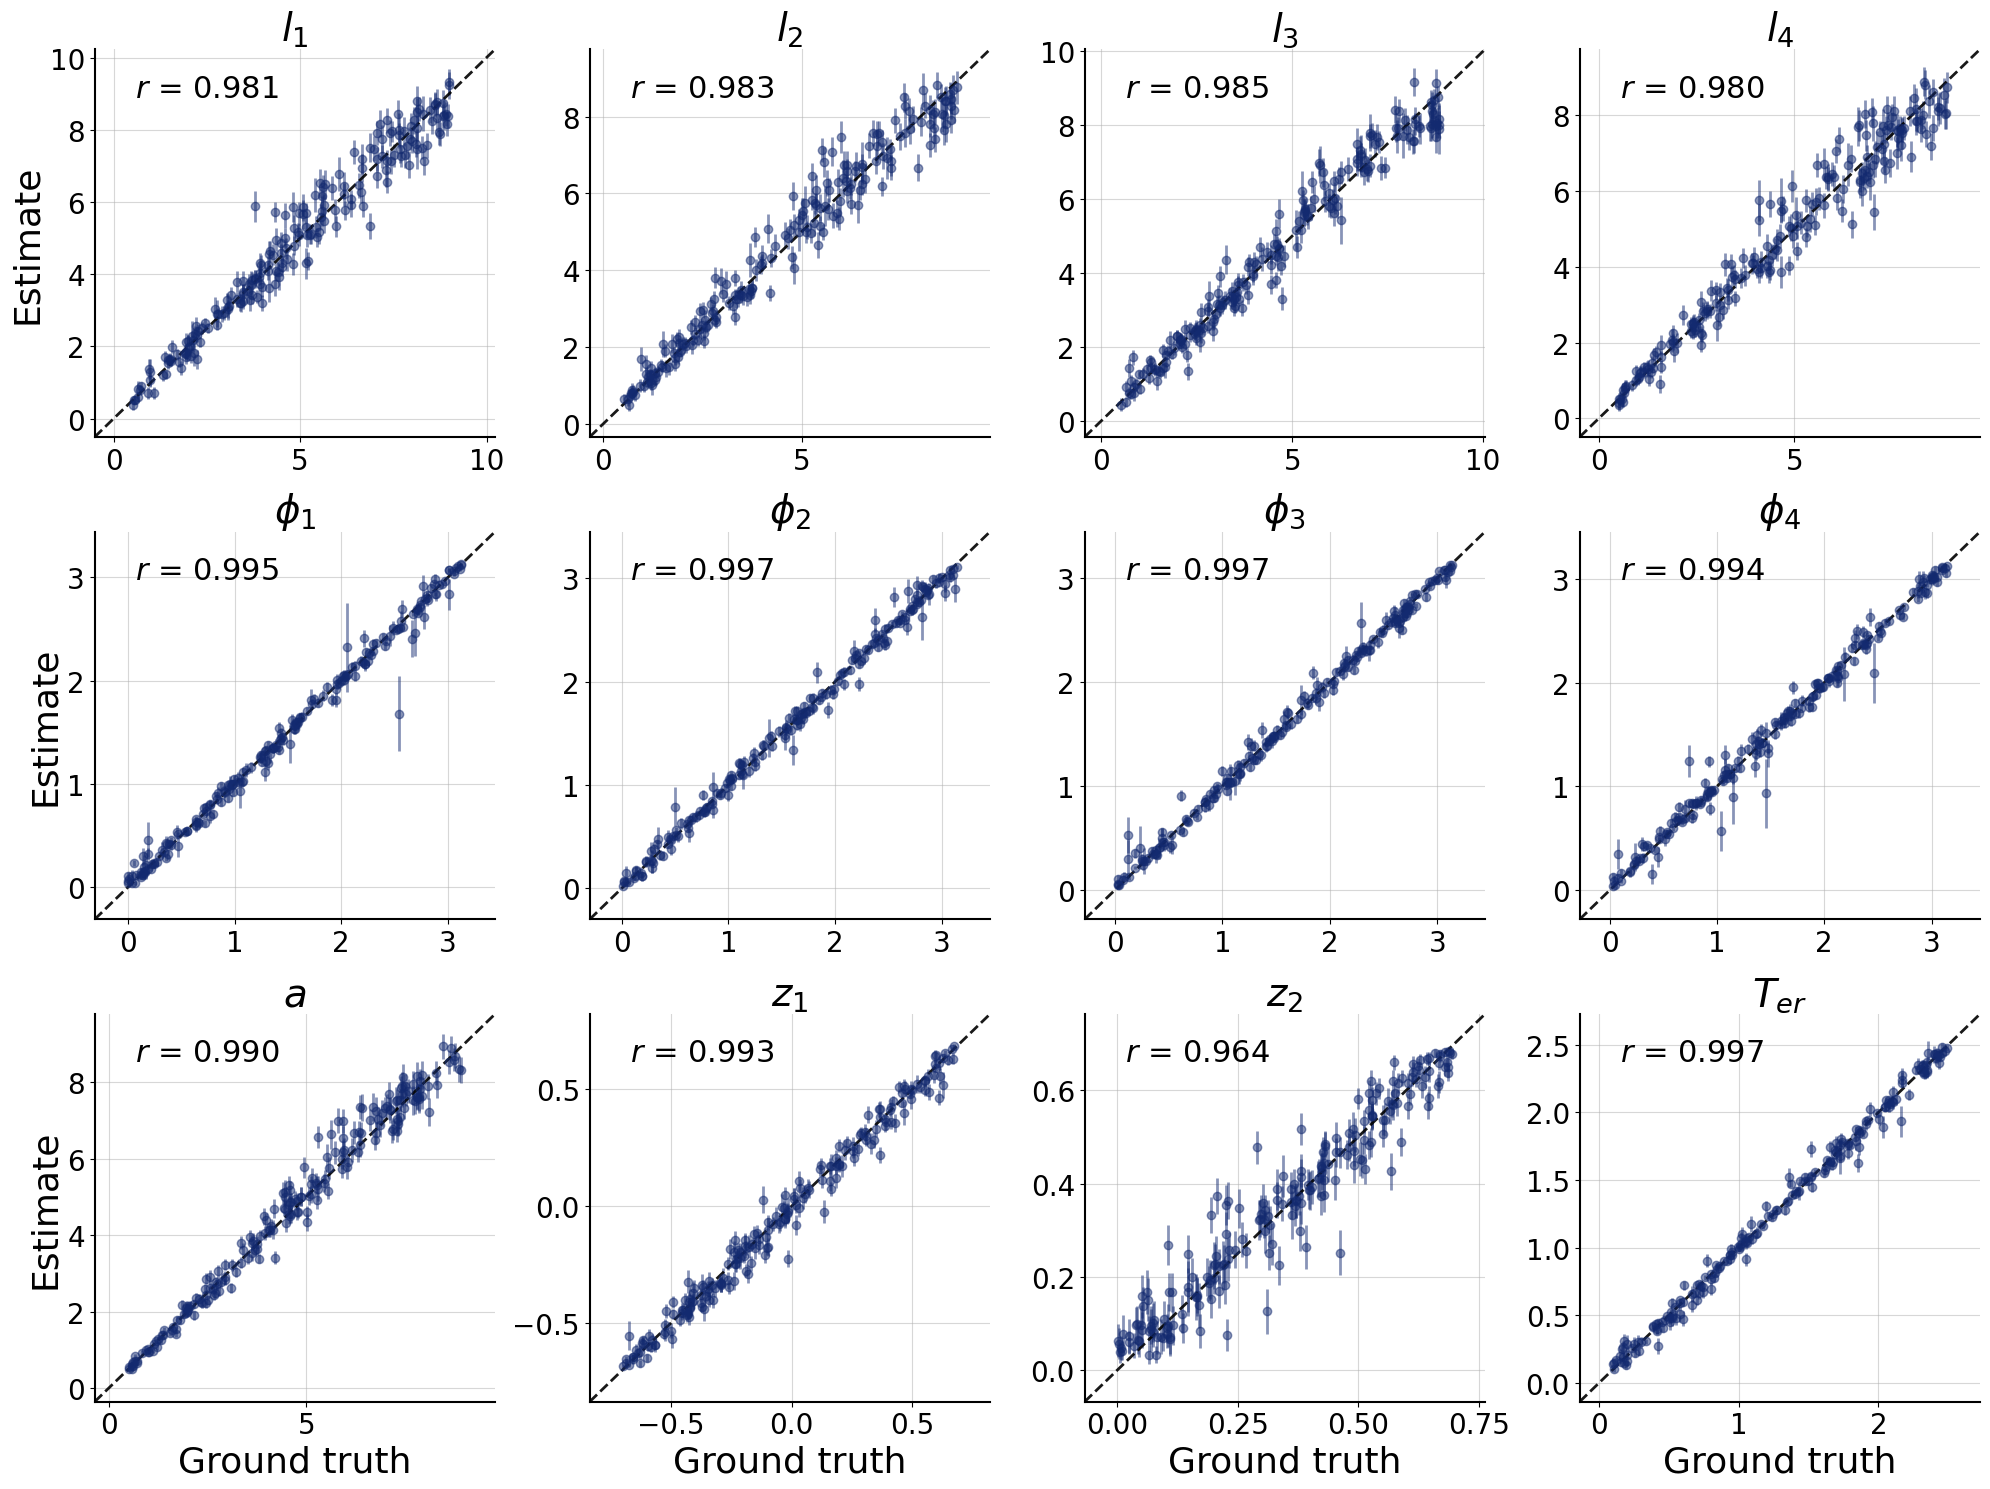

In [127]:
variable_names = [r'$l_1$', r'$l_2$', r'$l_3$', r'$l_4$', 
                  r'$\phi_1$', r'$\phi_2$', r'$\phi_3$', r'$\phi_4$',
                  r'$a$', r'$z_1$',r'$z_2$', r'$T_{er}$']

f = bf.diagnostics.plots.recovery(
    estimates=post_draws, 
    targets=val_sims,
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20

)

f.savefig('../plots/hcdm_recovery.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

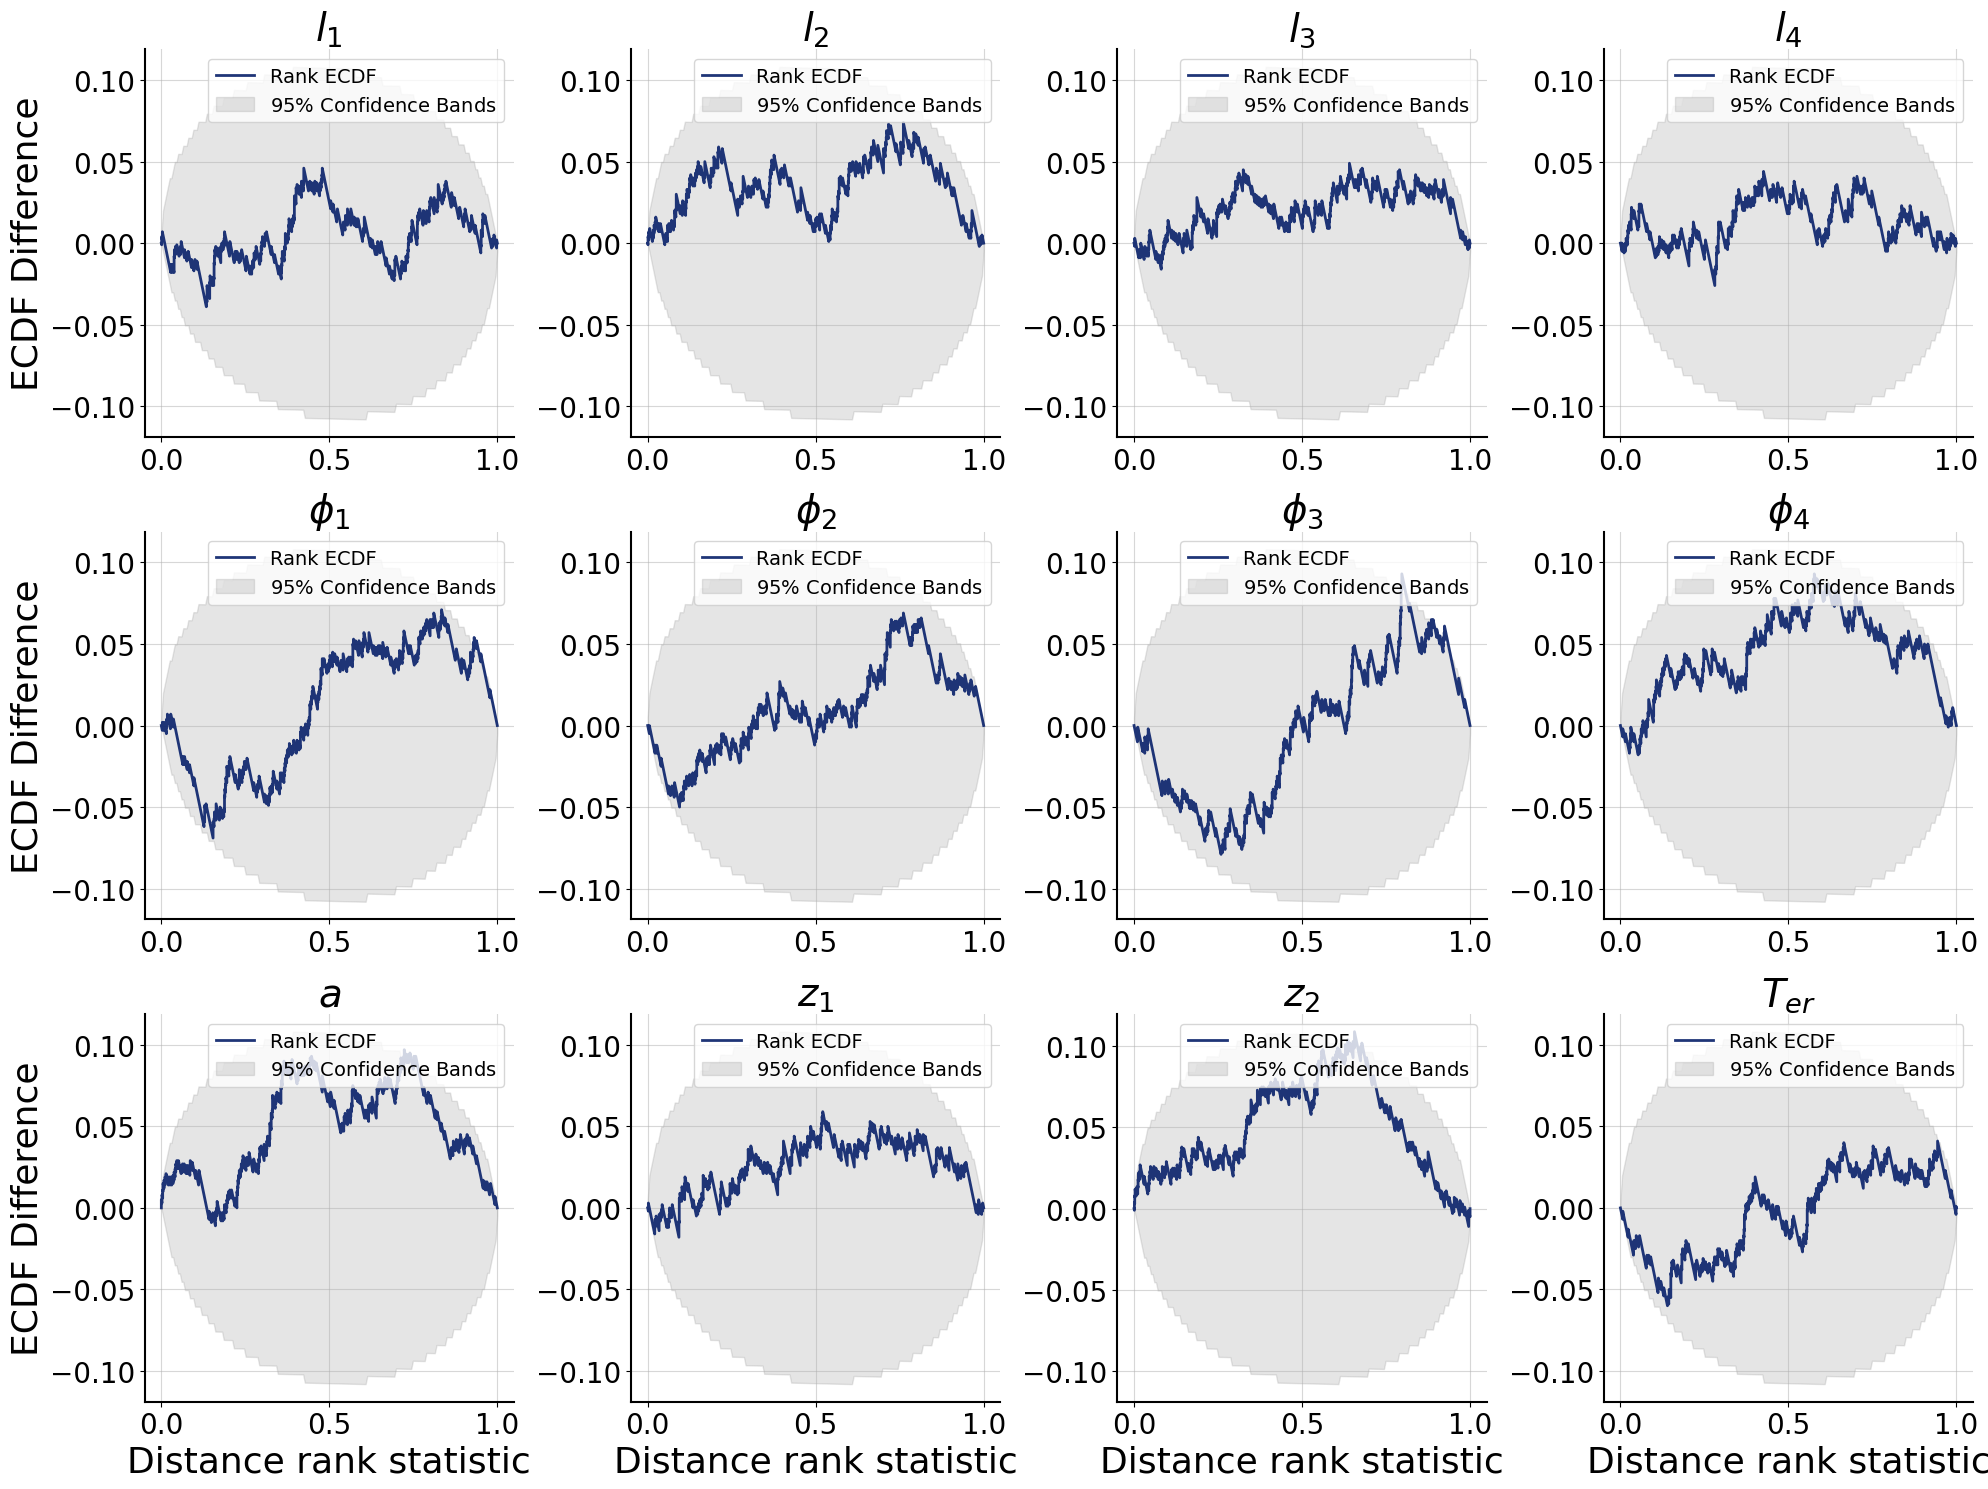

In [128]:
f = bf.diagnostics.plots.calibration_ecdf(
    estimates=post_draws, 
    targets=val_sims,
    difference = True,
    rank_type="distance",
    variable_names = variable_names,
    title_fontsize = 28,
    label_fontsize = 26,
    num_col = 4,
    metric_fontsize = 22,
    tick_fontsize = 20

)

f.savefig('../plots/hcdm_ecdf.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')

## data fitting

In [20]:
data = pd.read_table("../notebooks_gpu/affect_data_bf.txt", sep = " ")
data["affect"] = np.pi * data["affect"]/100

In [21]:
def data_organize(data):    
    grouped = data.groupby("participant")[["rt", "affect"]].agg(list)
    grouped_outcomes = data.groupby("participant")["outcome"].agg(list)
    outcome_values = np.array([-2, -1, 1, 2])
    outcome_to_index = {val: idx for idx, val in enumerate(outcome_values)}
    
    max_obs = 200
    rt_padded = np.zeros((len(grouped), max_obs))
    rt_min = np.zeros(len(grouped))
    resp_padded = np.zeros((len(grouped), max_obs))
    mask = np.zeros((len(grouped), max_obs), dtype=int)
    con = np.zeros((len(grouped), max_obs, 4), dtype=int)

    for i, (participant_id, outcomes) in enumerate(grouped_outcomes.items()):
    
        # Clip the actual number of trials to MAX_OBS if necessary (shouldn't be needed if MAX_OBS is determined correctly, but good practice).
        num_trials = min(len(outcomes), 200)
        
        # Iterate through the actual trials for the current participant
        for t in range(num_trials):
            outcome_val = outcomes[t]
            
            # Determine the column index for the current outcome
            col_index = outcome_to_index.get(outcome_val)
            
            # Only proceed if the outcome is one of the four expected values
            if col_index is not None:
                # Set the corresponding position in the 3D array to 1
                # (Participant index, Trial index, Outcome index)
                con[i, t, col_index] = 1

    
    for i, (_, row) in enumerate(grouped.iterrows()):
        rt_list = row["rt"]
        resp_list = row["affect"]
        n = min(len(rt_list), max_obs)
        rt_padded[i, :n] = rt_list[:n]
        resp_padded[i, :n] = resp_list[:n]
        rt_min[i] = np.min(row["rt"])
        mask[i, :n] = 1

    data_dict = {}
    data_dict["num_obs_per_condition"] = data.groupby("participant")["outcome"].value_counts().unstack(fill_value=0).to_numpy()
    data_dict["rt"] = rt_padded
    data_dict["resp"] = resp_padded
    data_dict["observed"] = mask
    data_dict["rt_min"] = rt_min.reshape((215,1))
    data_dict["con"] = con
    
    return data_dict
    
    


In [22]:
data_re = data_organize(data)
%time post_draws = workflow.sample(conditions=data_re, num_samples=1000)

CPU times: user 148 ms, sys: 47 ms, total: 195 ms
Wall time: 376 ms


In [23]:
#get the posterior mean
l = [np.mean(post_draws["l"], axis=1)[:,i] for i in range(4)] 
phi = [np.mean(post_draws["phi"], axis=1)[:,i] for i in range(4)] 
a = np.mean(post_draws["a"], axis = 1)[:,0]
z1, z2 = np.mean(post_draws["zx"], axis = 1)[:,0], np.mean(post_draws["zy"], axis = 1)[:,0]
Ter = np.mean(post_draws["ndt"], axis = 1)[:,0]

In [24]:
#select nine participants
l_sample = [l[i][1:10] for i in range(4)]
phi_sample = [phi[i][1:10] for i in range(4)]
a_sample = a[1:10]
z_sample = [z1[1:10],
            z2[1:10]]

x_arc, y_arc = a_sample.reshape(1,9) * np.cos(phi_sample), a_sample.reshape(1,9) * np.sin(phi_sample)
dx = x_arc - a_sample * z_sample[0]
dy = y_arc - a_sample * z_sample[1]
phi_prime_sample = np.arctan2(dy, dx)
        
radius = a_sample 
angles = np.linspace(0, np.pi, 300) 
x_circle = [radius[i] * np.cos(angles) for i in range(9)] 
y_circle = [radius[i] * np.sin(angles) for i in range(9)]

# Convert polar (r, theta) to Cartesian
x_start, y_start = z_sample[0] * a_sample, z_sample[1]* a_sample
x_end = x_start + l_sample * np.cos(phi_prime_sample) 
y_end = y_start + l_sample * np.sin(phi_prime_sample) 

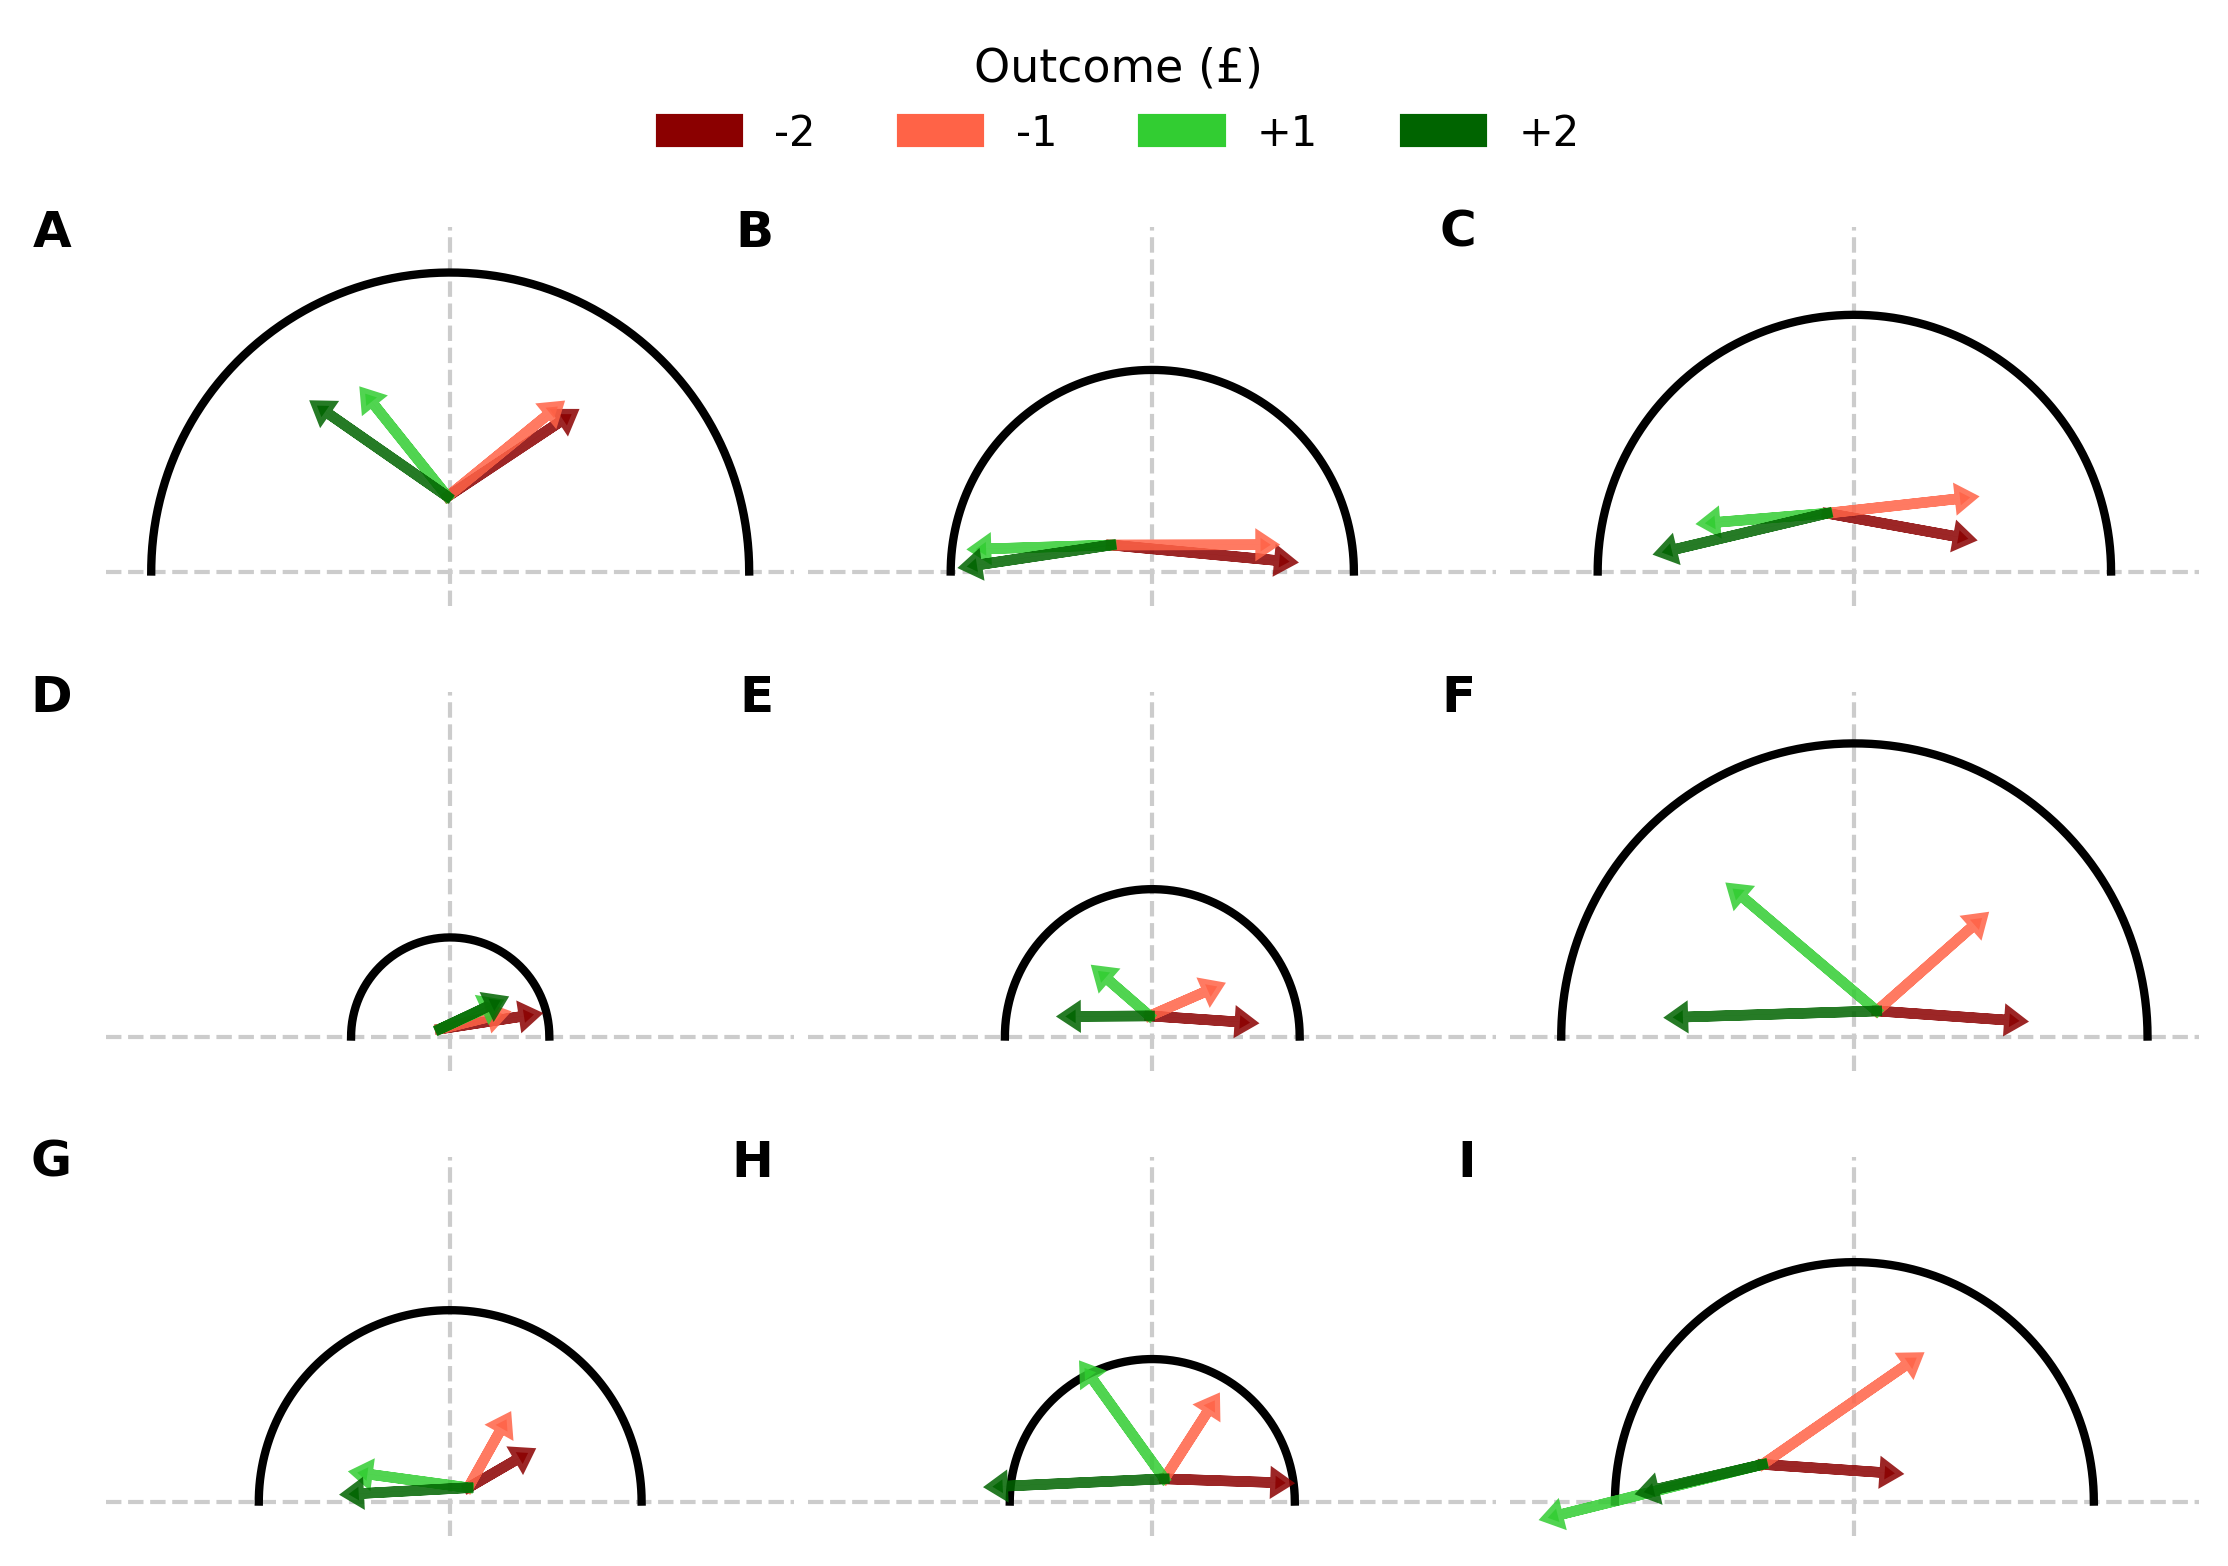

In [26]:
# Set publication-quality defaults
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['lines.linewidth'] = 2

# Create figure with higher DPI for better quality
fig, ax = plt.subplots(3, 3, figsize=(9, 6), dpi=300)
ax = ax.flatten()
colors = ['#8B0000', '#FF6347', '#32CD32', '#006400']  # or use plt.cm.Set2.colors

for i in range(9):    
    # Thicker semicircle line
    ax[i].plot(x_circle[i], y_circle[i], 'k', linewidth=2)
    
    # Lighter, thinner reference lines
    ax[i].axhline(0, color='#CCCCCC', linewidth=1, ls='--', zorder=0)
    ax[i].axvline(0, color='#CCCCCC', linewidth=1, ls='--', zorder=0)
    
    ax[i].set_xlim(-5, 5)
    ax[i].set_ylim(-0.5, 5)
    ax[i].set_aspect('equal')
    ax[i].axis('off')

# Plot vectors with consistent styling
for i in range(9):
    for j in range(4):
        ax[i].arrow(x_start[i], y_start[i], 
                 x_end[j, i] - x_start[i], y_end[j, i] - y_start[i],
                 head_width=0.2, head_length=0.15,
                 length_includes_head=True,
                 color=colors[j % len(colors)], 
                 linewidth=2.5,
                 alpha=0.85,
                 zorder=2)

# Tighter layout
plt.subplots_adjust(wspace=0.02, hspace=0.02)

# Optional: Add panel labels (A, B, C, etc.)
for i, axis in enumerate(ax):
    axis.text(-0.05, 1.05, chr(65+i), transform=axis.transAxes,
              fontsize=12, fontweight='bold', va='top', ha='right')

labels = ['-2', '-1', '+1', '+2']

# Create custom legend handles
from matplotlib.patches import Patch
handles = [Patch(color=colors[j % len(colors)], label=labels[j]) for j in range(4)]

# Place the legend outside the grid
fig.legend(handles=handles, 
           title='Outcome (£)',
           loc='upper center',        # position below all subplots
           bbox_to_anchor=(0.5, 0.98),
           ncol=4,                    # put all labels in one row
           frameon=False,             # remove legend box border
           fontsize=10,
           title_fontsize=11)

# Save in multiple formats
plt.savefig('../plots/semicircle_vectors.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

## Correlation between estimates and empirical summary statistics

In [27]:
resp_arr = data_re["resp"]        # (215, T)
rt_arr   = data_re["rt"]          # (215, T)
con_arr  = data_re["con"]         # (215, T, 4)

# Expand for broadcasting
resp_exp = resp_arr[:, :, None]   # (215, T, 1)
rt_exp   = rt_arr[:, :, None]     # (215, T, 1)

# Mask by condition
resp_masked = np.where(con_arr == 1, resp_exp, np.nan)  # (215, T, 4)
rt_masked   = np.where(con_arr == 1, rt_exp,   np.nan)

# ---- statistics ----
mean_resp = np.nanmean(resp_masked, axis=1)   # (215, 4)
var_resp  = np.nanvar(resp_masked,  axis=1)

mean_rt   = np.nanmean(rt_masked, axis=1)
var_rt    = np.nanvar(rt_masked,  axis=1)

a_repeat = np.repeat(np.mean(post_draws["a"], axis=1), 4, axis = 1)
z1_repeat = np.repeat(np.mean(post_draws["zx"], axis=1), 4, axis = 1)
z2_repeat = np.repeat(np.mean(post_draws["zy"], axis=1), 4, axis = 1)
Ter_repeat = np.repeat(np.mean(post_draws["ndt"], axis=1), 4, axis = 1)
Ter_repeat = np.repeat(np.mean(post_draws["ndt"], axis=1), 4, axis = 1)
drift_a_ratio = np.mean(post_draws["l"], axis =1)/np.mean(post_draws["a"], axis=1)

In [28]:
ndt = np.tile(np.mean(post_draws["ndt"], axis=1), (1,4))
mean_rt = mean_rt - ndt

In [29]:
def dict_cor(target):
    predictors = {
        "l": np.mean(post_draws["l"], axis=1).flatten(),
        "phi": np.mean(post_draws["phi"], axis=1).flatten(),
        "a": a_repeat.flatten(),
        "z1": z1_repeat.flatten(),
        "z2": z2_repeat.flatten(),
        "Ter": Ter_repeat.flatten(),
        "drift_a_ratio": drift_a_ratio.flatten(),
    }
    
    corrs = {
        name: np.round(np.corrcoef(target.flatten(), values)[0, 1], 3)
        for name, values in predictors.items()
    }
    return corrs

In [30]:
dict_cor(mean_rt)

{'l': 0.178,
 'phi': -0.015,
 'a': 0.565,
 'z1': -0.047,
 'z2': -0.227,
 'Ter': -0.179,
 'drift_a_ratio': -0.61}

In [31]:
dict_cor(var_rt)

{'l': -0.43,
 'phi': 0.007,
 'a': -0.075,
 'z1': 0.087,
 'z2': -0.055,
 'Ter': -0.036,
 'drift_a_ratio': -0.54}

In [32]:
dict_cor(mean_resp)

{'l': 0.013,
 'phi': 0.989,
 'a': 0.016,
 'z1': -0.188,
 'z2': 0.036,
 'Ter': -0.012,
 'drift_a_ratio': 0.035}

In [33]:
dict_cor(var_resp)

{'l': -0.529,
 'phi': -0.105,
 'a': -0.499,
 'z1': 0.098,
 'z2': -0.159,
 'Ter': 0.308,
 'drift_a_ratio': -0.088}

### Plot of correlation

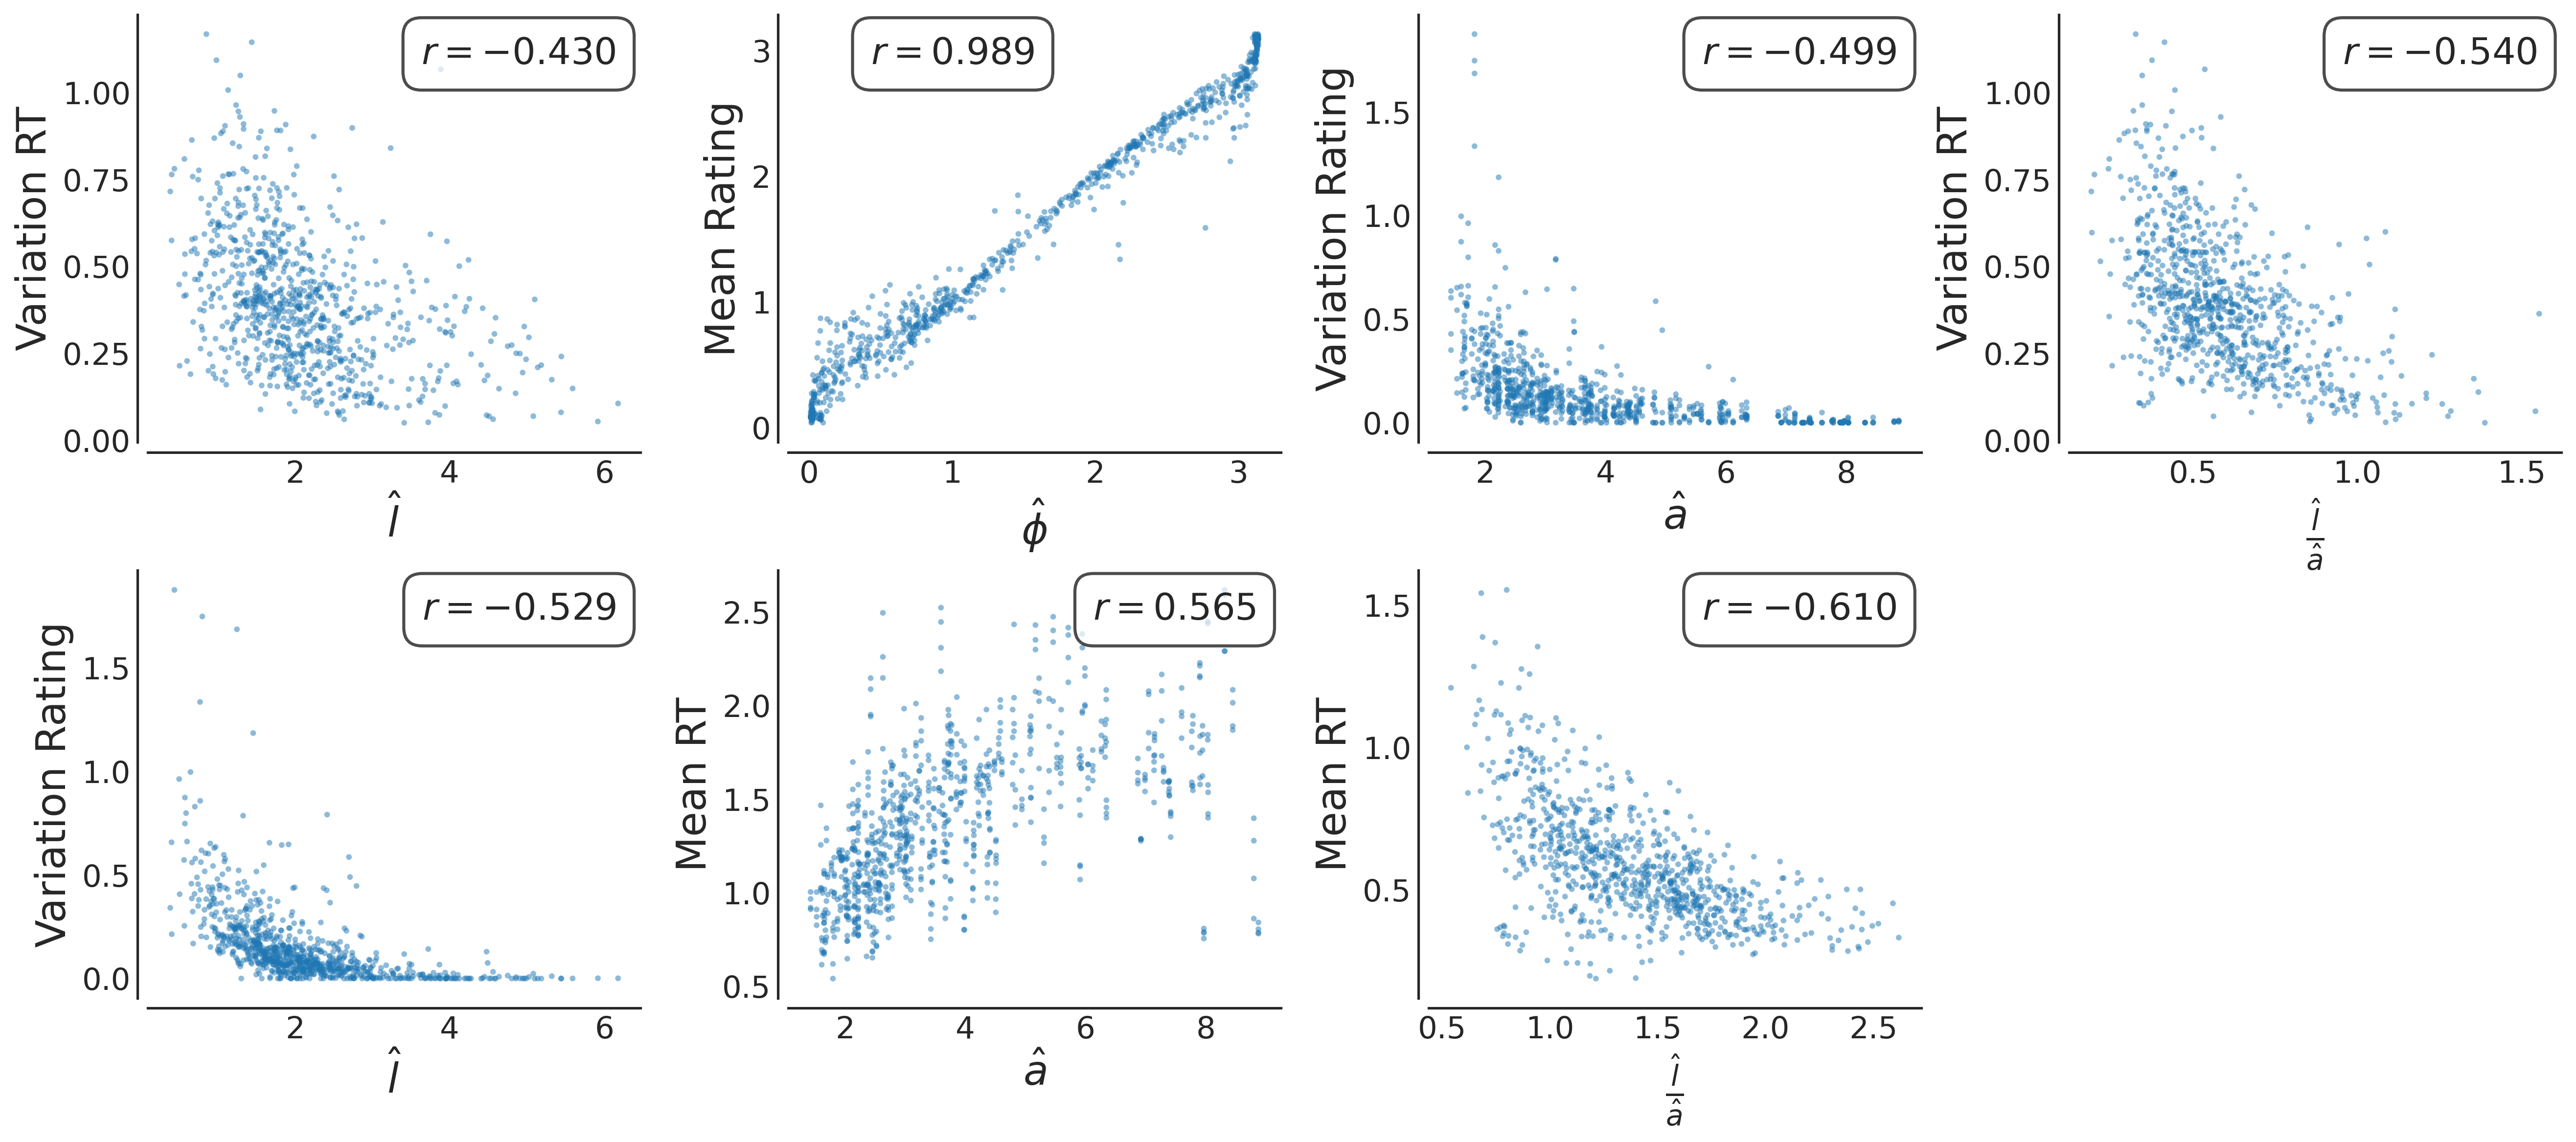

In [151]:
fig, ax = plt.subplots(2, 4, figsize=(18, 8), dpi=300)
plt.style.use("seaborn-v0_8-white")

# Common style
marker_kws = dict(s=8, alpha=0.5, edgecolors='none')
BBOX_PROPS = dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.7, edgecolor='black', linewidth=1.5)
CORR_TEXT_KWS = dict( horizontalalignment='right', verticalalignment='top')

ax[0, 0].scatter(np.mean(post_draws["l"], axis=1).flatten(),var_rt.flatten(), **marker_kws)
ax[0, 0].set_ylabel("Variation RT", fontsize=20)
ax[0, 0].set_xlabel(r'$\hat{l}$', fontsize=20)
ax[0, 0].text(0.95, 0.95,f'$r = {dict_cor(var_rt)["l"]:.3f}$', size = 18, bbox=BBOX_PROPS, transform=ax[0, 0].transAxes, **CORR_TEXT_KWS)


ax[1, 0].scatter(np.mean(post_draws["l"], axis=1).flatten(), var_resp.flatten(), **marker_kws)
ax[1, 0].set_ylabel("Variation Rating", fontsize=20)
ax[1, 0].set_xlabel(r'$\hat{l}$', fontsize=20)
ax[1, 0].text(0.95, 0.95,f'$r = {dict_cor(var_resp)["l"]:.3f}$', size = 18, bbox=BBOX_PROPS, transform=ax[1, 0].transAxes, **CORR_TEXT_KWS)


ax[0, 1].scatter(np.mean(post_draws["phi"], axis=1).flatten(), mean_resp.flatten(), **marker_kws)
ax[0, 1].set_ylabel("Mean Rating", fontsize=20)
ax[0, 1].set_xlabel(r'$\hat{\phi}$', fontsize=20)
ax[0, 1].text(0.5, 0.95,f'$r = {dict_cor(mean_resp)["phi"]:.3f}$', size = 18, bbox=BBOX_PROPS, transform=ax[0, 1].transAxes, **CORR_TEXT_KWS)


ax[1, 1].scatter(np.tile(np.mean(post_draws["a"], axis=1), (1,4)).flatten(), mean_rt.flatten(), **marker_kws)
ax[1, 1].set_ylabel("Mean RT", fontsize=20)
ax[1, 1].set_xlabel(r'$\hat{a}$', fontsize=20)
ax[1, 1].text(0.95, 0.95,f'$r = {dict_cor(mean_rt)["a"]:.3f}$', size = 18, bbox=BBOX_PROPS, transform=ax[1, 1].transAxes, **CORR_TEXT_KWS)


ax[0, 2].scatter(np.tile(np.mean(post_draws["a"], axis=1), (1,4)).flatten(), var_resp.flatten(), **marker_kws)
ax[0, 2].set_ylabel("Variation Rating", fontsize=20)
ax[0, 2].set_xlabel(r'$\hat{a}$', fontsize=20)
ax[0, 2].text(0.95, 0.95,f'$r = {dict_cor(var_resp)["a"]:.3f}$', size = 18, bbox=BBOX_PROPS, transform=ax[0, 2].transAxes, **CORR_TEXT_KWS)


ax[1, 2].scatter(mean_rt.flatten(),
                 drift_a_ratio.flatten(), **marker_kws)
ax[1, 2].set_ylabel("Mean RT", fontsize=20)
ax[1, 2].set_xlabel(r'$\frac{\hat{l}}{\hat{a}}$', fontsize=20)
ax[1, 2].text(0.95, 0.95,f'$r = {dict_cor(mean_rt)["drift_a_ratio"]:.3f}$', size = 18, bbox=BBOX_PROPS, transform=ax[1, 2].transAxes, **CORR_TEXT_KWS)


ax[0, 3].scatter(drift_a_ratio.flatten(), var_rt.flatten(), **marker_kws)
ax[0, 3].set_ylabel("Variation RT", fontsize=20)
ax[0, 3].set_xlabel(r'$\frac{\hat{l}}{\hat{a}}$', fontsize=20)
ax[0, 3].text(0.95, 0.95,f'$r = {dict_cor(var_rt)["drift_a_ratio"]:.3f}$', size = 18, bbox=BBOX_PROPS, transform=ax[0, 3].transAxes, **CORR_TEXT_KWS)


# Polish axes
for a in ax.flatten():
    a.tick_params(labelsize=15)
    sns.despine(ax=a, offset=5)  # clean up top/right borders

plt.tight_layout(pad=1.5)
plt.subplots_adjust(wspace=0.3, hspace=0.3)

for ax in fig.axes:
    if not ax.has_data():
        ax.remove()
plt.savefig('../plots/hcdm_correlation.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()


## Posterior predictive checking

Posterior draws as the prior:

In [152]:
def ppc(batch_info):
    theta = prior                # batched
    batch_size = theta["l"].shape[0]
    num_obs_per_condition = np.random.randint(min_obs_per_condition, max_obs_per_condition, size = 4)
    simulated_data = cuda_simulator(**theta, num_obs_per_condition = num_obs_per_condition, rng=RNG)  # batched model
    return {
    "num_obs_per_condition": np.tile(num_obs_per_condition, [batch_size,1]),   # give it a key!
    **theta,
    **simulated_data
    }


In [153]:
post_draws = workflow.sample(conditions=data_re, num_samples=2000)

prior = {}
n_replicates = 100
mean_rt_ppc = np.zeros((n_replicates, 215,4))
std_rt_ppc = np.zeros((n_replicates, 215,4))
mean_resp_ppc = np.zeros((n_replicates, 215,4))
std_resp_ppc = np.zeros((n_replicates, 215,4))

quantiles_rt_ppc = np.zeros((n_replicates, 215,4, 5))
quantiles_resp_ppc = np.zeros((n_replicates, 215,4, 5))
quantile = [0.1, 0.3, 0.5, 0.7, 0.9]


for i in range(n_replicates):
    for key in post_draws.keys():
        idx = np.random.randint(0, post_draws[key].shape[1], size=post_draws[key].shape[0])
        prior[key] = post_draws[key][np.arange(post_draws[key].shape[0]), idx]
    ppc_simulated = ppc(1)
    for n in range(215):
        for c in range(4):
            mean_rt_ppc[i,n,c] = np.mean(data_re["rt"][n,:][data_re["con"][n,:,c] == 1])
            std_rt_ppc[i,n,c] = np.std(data_re["rt"][n,:][data_re["con"][n,:,c] == 1])
    
            mean_resp_ppc[i,n,c] = np.mean(ppc_simulated["rt"][n,:][ppc_simulated["con"][n,:,c] == 1])
            std_resp_ppc[i,n,c] = np.std(ppc_simulated["rt"][n,:][ppc_simulated["con"][n,:,c] == 1])
            for q in range(5):
                quantiles_rt_ppc[i,n,c,q] = np.quantile(ppc_simulated["rt"][n,:][ppc_simulated["con"][n,:,c] == 1], quantile[q])
                quantiles_resp_ppc[i,n,c,q] = np.quantile(ppc_simulated["resp"][n,:][ppc_simulated["con"][n,:,c] == 1], quantile[q])



In [154]:
ppc_simulated_hcdm = ppc_simulated
%store ppc_simulated_hcdm

Stored 'ppc_simulated_hcdm' (dict)


### Mean and standard deviation

In [155]:
mean_rt_obs = np.zeros((215,4))

std_rt_obs = np.zeros((215,4))

mean_resp_obs = np.zeros((215,4))

std_resp_obs = np.zeros((215,4))

for n in range(215):
    for c in range(4):
        #response
        mean_resp_obs[n,c] = np.mean(data_re["resp"][n,:][data_re["con"][n,:,c] == 1])
        std_resp_obs[n,c] = np.std(data_re["resp"][n,:][data_re["con"][n,:,c] == 1])
        #rt
        mean_rt_obs[n,c] = np.mean(data_re["rt"][n,:][data_re["con"][n,:,c] == 1])
        std_rt_obs[n,c] = np.std(data_re["rt"][n,:][data_re["con"][n,:,c] == 1])


### Quantiles: 0.1, 0.3, 0.5, 0.7, 0.9

In [156]:
quantiles_rt_obs = np.zeros((215,4, 5))
quantiles_resp_obs = np.zeros((215,4, 5))

quantile = [0.1, 0.3, 0.5, 0.7, 0.9]

for n in range(215):
    for c in range(4):
        for q in range(5):
            #response
            quantiles_rt_obs[n,c,q] = np.quantile(data_re["rt"][n,:][data_re["con"][n,:,c] == 1], quantile[q])
            quantiles_resp_obs[n,c,q] = np.quantile(data_re["resp"][n,:][data_re["con"][n,:,c] == 1], quantile[q])
    


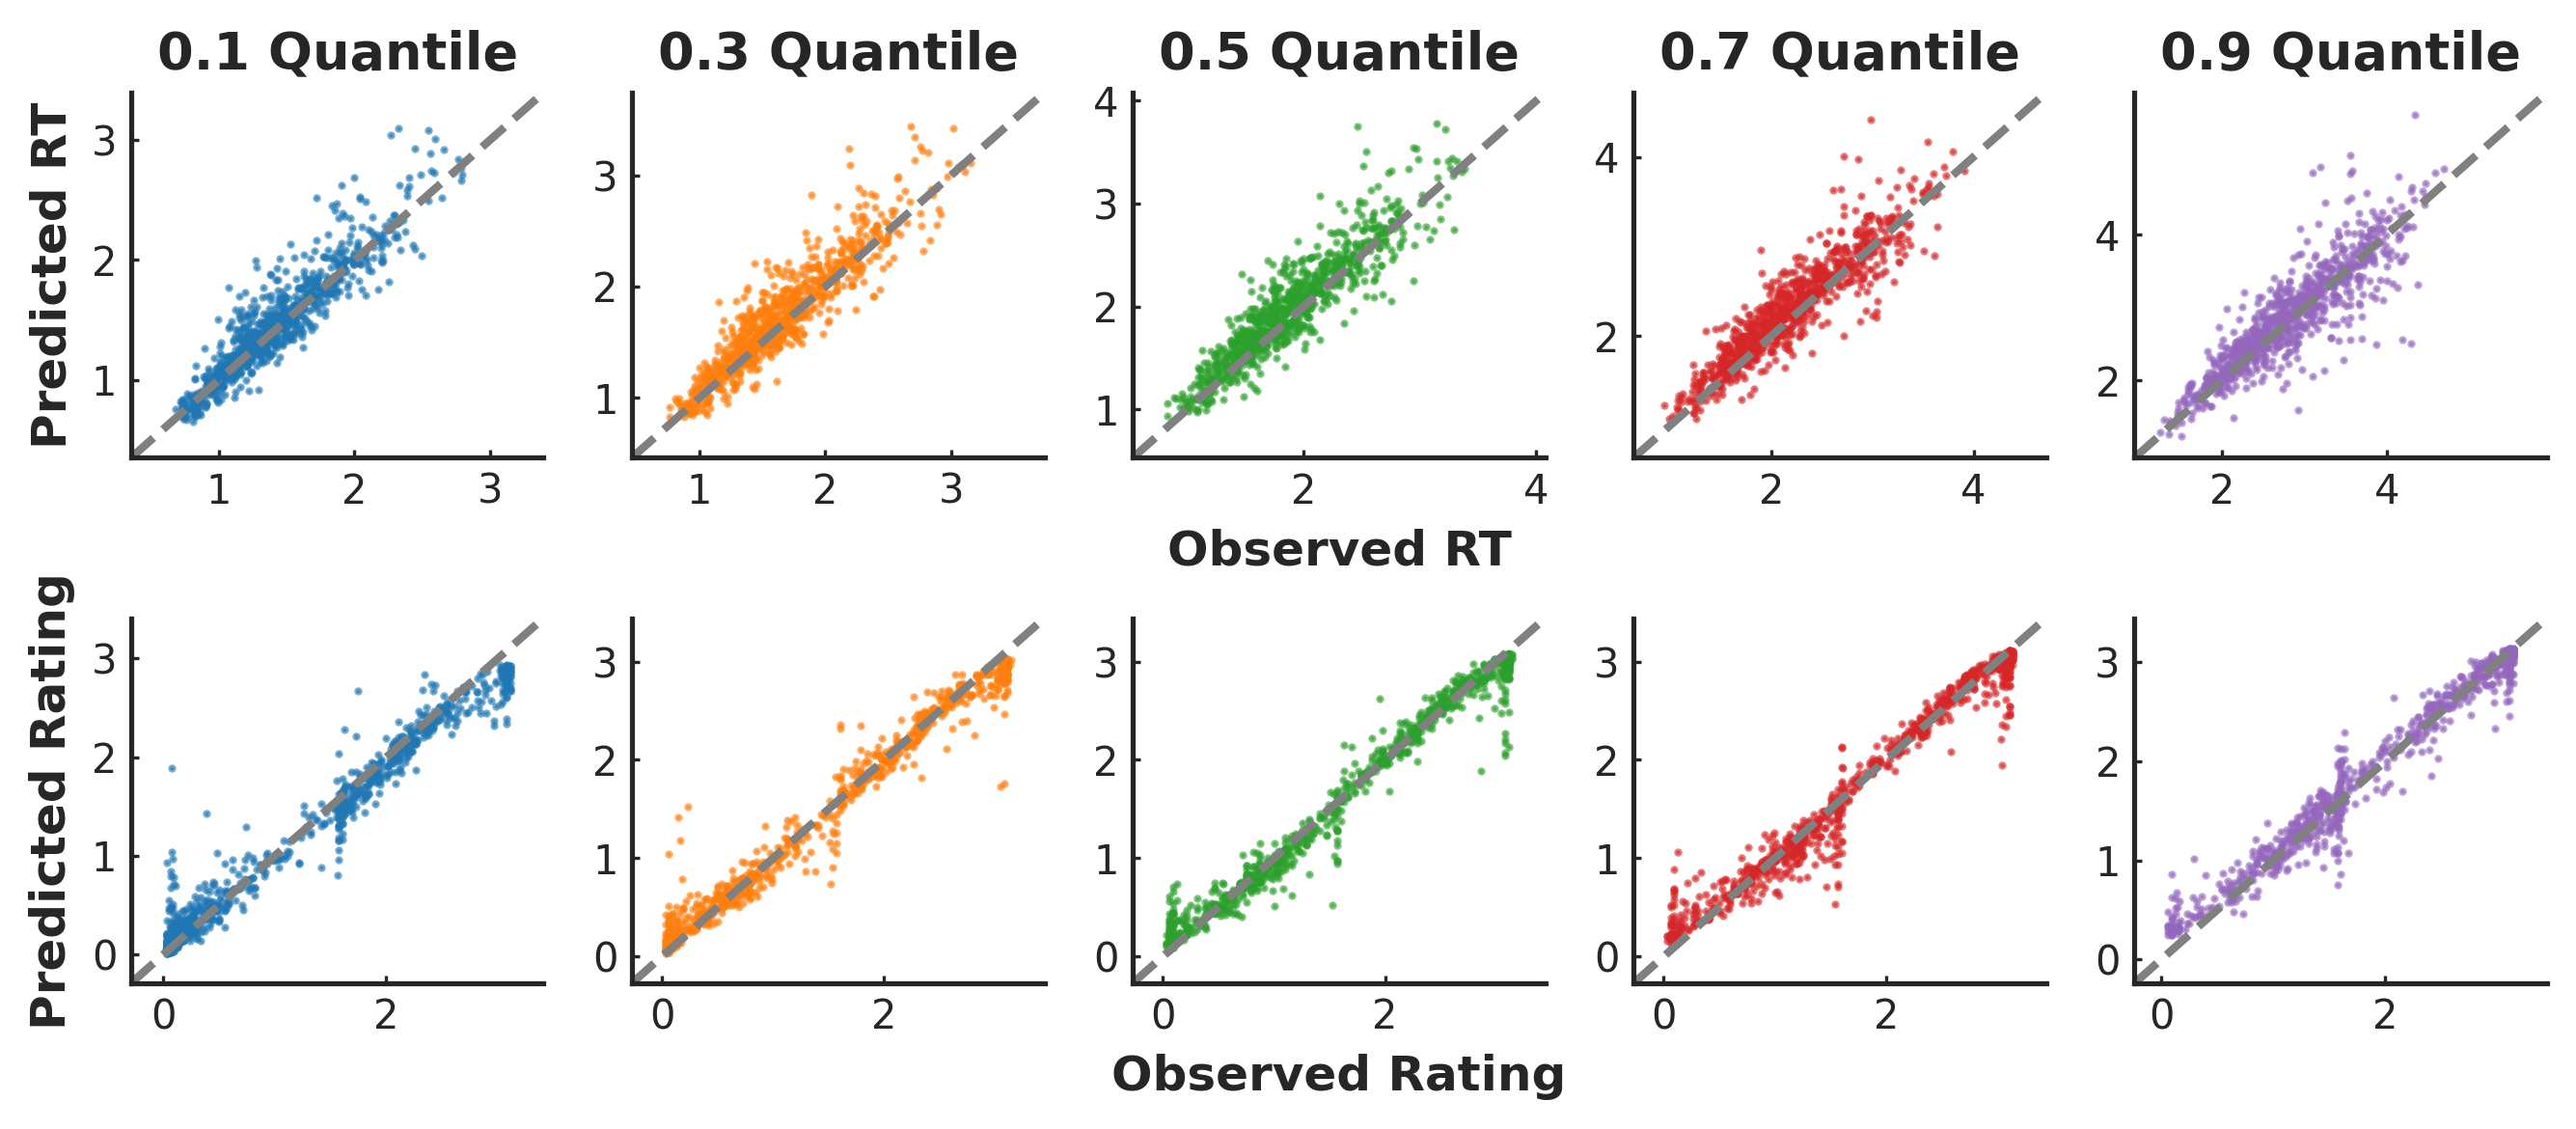

In [157]:
fig, ax = plt.subplots(2, 5, figsize = (9, 4), dpi = 300)
colors = plt.cm.tab10.colors 

for i in range(5):
    quantiles_rt_ppc_mean = np.mean(quantiles_rt_ppc[:,:,:,i], axis = 0)
    ax[0, i].scatter(quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean,
                    s = 1, alpha = 0.6, color = colors[i])
    ax[0, i].axline((1,1), slope=1, ls = "--", color = "grey")
    ax[0, i].set_title(f"{quantile[i]} Quantile", size = 13, weight = "bold")
    ax[0, i].set_xlim(np.min(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten())+0.3)
    ax[0, i].set_ylim(np.min(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_rt_obs[:,:,i], quantiles_rt_ppc_mean)).flatten())+0.3)
    ax[0, 2].set_xlabel("Observed RT", size = 12, weight = "bold")
    ax[0, 0].set_ylabel("Predicted RT", size = 12, weight = "bold")
    
for i in range(5):
    quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc[:,:,:,i], axis = 0)
    ax[1, i].scatter(quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean,
                    s = 1, alpha = 0.6, color = colors[i])
    ax[1, i].axline((1,1), slope=1, ls = "--", color = "grey")
    ax[1, i].set_xlim(np.min(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten())+0.3)
    ax[1, i].set_ylim(np.min(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten()) -0.3, np.max(np.vstack((quantiles_resp_obs[:,:,i], quantiles_resp_ppc_mean)).flatten())+0.3)
    ax[1, 2].set_xlabel("Observed Rating", size = 12, weight = "bold")
    ax[1, 0].set_ylabel("Predicted Rating", size = 12, weight = "bold")

for a in ax.flatten():
    #a.set_aspect("equal", adjustable="box")
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.tick_params(direction="in", length=2)
    
plt.tight_layout()
plt.savefig('../plots/quantile_hcdm.pdf', bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

### Quantify the goodness of fit

In [158]:
quantiles_resp_ppc_mean = np.mean(quantiles_resp_ppc, axis = 0)
gof_resp_hcdm = np.mean(np.mean(abs(quantiles_resp_obs - quantiles_resp_ppc_mean), axis = 1), axis = 1)
%store gof_resp_hcdm

Stored 'gof_resp_hcdm' (ndarray)


In [159]:
quantiles_rt_ppc_mean = np.mean(quantiles_rt_ppc, axis = 0)
gof_rt_hcdm = np.mean(np.mean(abs(quantiles_rt_obs - quantiles_rt_ppc_mean), axis = 1), axis = 1)
%store gof_rt_hcdm

Stored 'gof_rt_hcdm' (ndarray)
